In [24]:
import pandas as pd
import matplotlib.pyplot as plt


In [25]:
trader_df = pd.read_csv("C:/Users/SUMEDHA HEMADRI/Downloads/historical_data.csv")
sentiment_df = pd.read_csv("C:/Users/SUMEDHA HEMADRI/Downloads/fear_greed_index.csv")
print("Trader Data:",trader_df.columns)
print("Sentiment Data:",sentiment_df.columns)
print("\nTrader Data Info:")
print(trader_df.info())
print("\nSentiment Data Info:")
print(sentiment_df.info())



Trader Data: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Sentiment Data: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trader Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         21122

In [26]:
trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'])
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])


 


In [27]:
 
merged_df = pd.merge(
    trader_df,
    sentiment_df,
    left_on=trader_df['Timestamp'].dt.date,
    right_on=sentiment_df['date'].dt.date,
    how='inner'
)

merged_df.head()



,key_0,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp,value,classification,date


In [28]:
sentiment_analysis = merged_df.groupby('classification')['Closed PnL'].mean().reset_index()
print(sentiment_analysis)



Empty DataFrame
Columns: [classification, Closed PnL]
Index: []


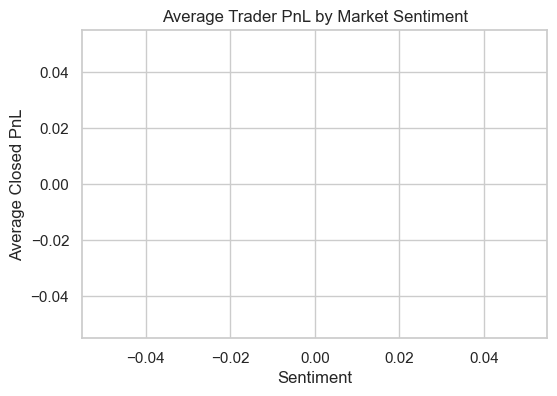

In [29]:
plt.figure(figsize=(6,4))
plt.bar(sentiment_analysis['classification'], sentiment_analysis['Closed PnL'])
plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()


In [30]:
merged_df.to_csv("merged_bitcoin_analysis.csv", index=False)
sentiment_analysis.to_csv("sentiment_pnl_summary.csv", index=False)


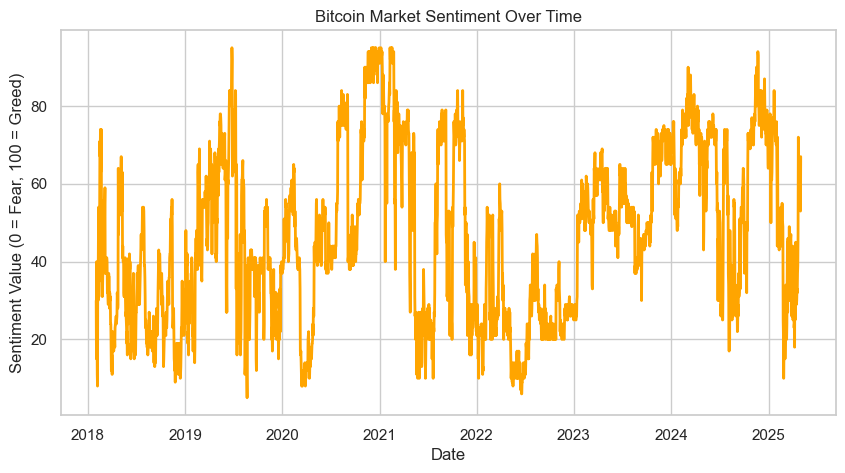

In [31]:
plt.figure(figsize=(10,5))
plt.plot(sentiment_df['date'], sentiment_df['value'], color='orange', linewidth=2)
plt.title('Bitcoin Market Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment Value (0 = Fear, 100 = Greed)')
plt.grid(True)
plt.show()


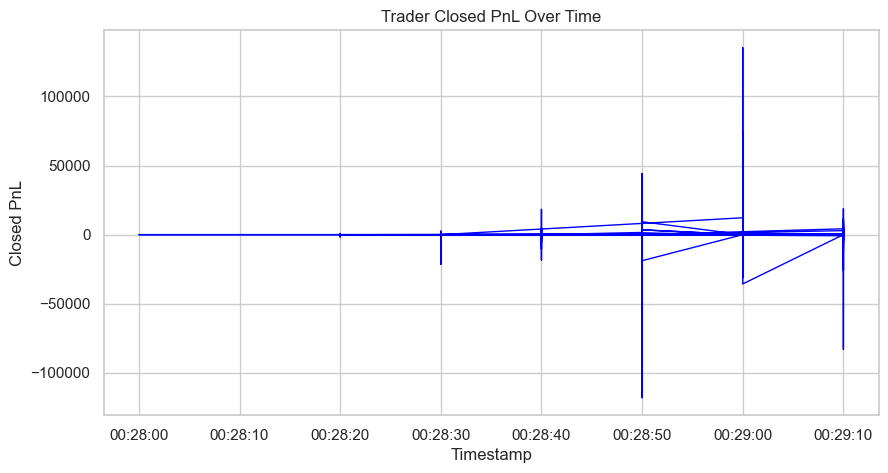

In [19]:
plt.figure(figsize=(10,5))
plt.plot(trader_df['Timestamp'], trader_df['Closed PnL'], color='blue', linewidth=1)
plt.title('Trader Closed PnL Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Closed PnL')
plt.grid(True)
plt.show()


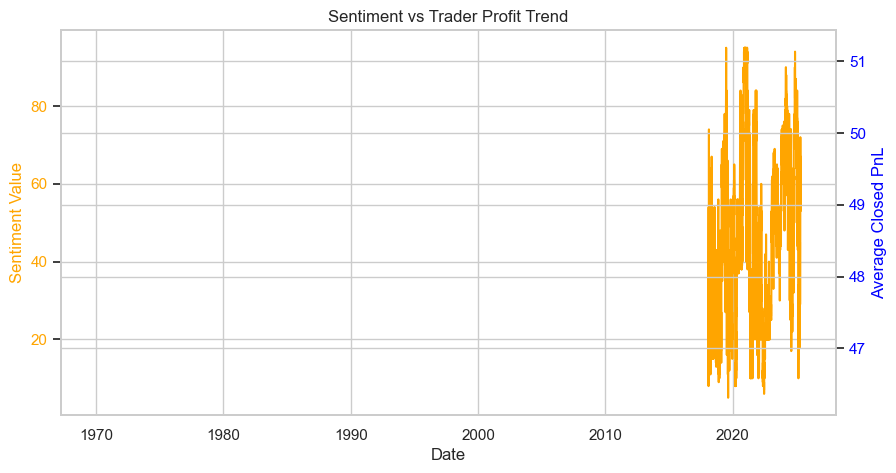

In [32]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.set_xlabel('Date')
ax1.set_ylabel('Sentiment Value', color='orange')
ax1.plot(sentiment_df['date'], sentiment_df['value'], color='orange', label='Sentiment')
ax1.tick_params(axis='y', labelcolor='orange')

 
ax2 = ax1.twinx()
daily_pnl = trader_df.groupby(trader_df['Timestamp'].dt.date)['Closed PnL'].mean()
ax2.set_ylabel('Average Closed PnL', color='blue')
ax2.plot(daily_pnl.index, daily_pnl.values, color='blue', label='Trader PnL')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Sentiment vs Trader Profit Trend')
plt.grid(True)
plt.show()


In [22]:
daily_sentiment = sentiment_df.groupby(sentiment_df['date'].dt.date)['value'].mean()
daily_pnl = trader_df.groupby(trader_df['Timestamp'].dt.date)['Closed PnL'].mean()

combined = pd.DataFrame({
    'Sentiment': daily_sentiment,
    'PnL': daily_pnl
}).dropna()

correlation = combined.corr().iloc[0,1]
print(f"Correlation between Sentiment and Trader PnL: {correlation:.2f}")


Correlation between Sentiment and Trader PnL: nan


In [23]:
plt.savefig('sentiment_vs_pnl_trend.png')
combined.to_csv('sentiment_pnl_correlation.csv', index=False)


<Figure size 640x480 with 0 Axes>